In [1]:
!pip install pandas numpy scikit-learn matplotlib seaborn

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

In [8]:
df = pd.read_csv("Groundwater_India_Data.csv")

print("Dataset shape:", df.shape)

df.head()

Dataset shape: (1000, 15)


,time_idx,station_id,datetime,target,rainfall,t kmnpnn]2m,t2m_max,t2m_min,month,latitude,longitude,wellDepth,wellAquiferType_encoded,State_encoded,District_encoded
0,0,CGWHYD0426,14-07-2023,-11.3050,0.02,30.62,36.39,24.98,7,14.9083,78.0083,31.0,0,0,0
1,1,CGWHYD0426,15-07-2023,-11.2775,4.11,30.44,36.97,25.01,7,14.9083,78.0083,31.0,0,0,0
2,2,CGWHYD0426,16-07-2023,-11.2675,0.09,29.04,34.03,24.77,7,14.9083,78.0083,31.0,0,0,0
3,3,CGWHYD0426,17-07-2023,-11.2775,2.32,30.10,36.50,24.52,7,14.9083,78.0083,31.0,0,0,0
4,4,CGWHYD0426,18-07-2023,-11.2800,0.95,29.03,34.79,24.82,7,14.9083,78.0083,31.0,0,0,0


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 15 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   time_idx                 1000 non-null   int64  
 1   station_id               1000 non-null   object 
 2   datetime                 1000 non-null   object 
 3   target                   1000 non-null   float64
 4   rainfall                 1000 non-null   float64
 5   t  kmnpnn]2m             1000 non-null   float64
 6   t2m_max                  1000 non-null   float64
 7   t2m_min                  1000 non-null   float64
 8   month                    1000 non-null   int64  
 9   latitude                 1000 non-null   float64
 10  longitude                1000 non-null   float64
 11  wellDepth                1000 non-null   float64
 12  wellAquiferType_encoded  1000 non-null   int64  
 13  State_encoded            1000 non-null   int64  
 14  District_encoded         

In [10]:
df.describe()

,time_idx,target,rainfall,t kmnpnn]2m,t2m_max,t2m_min,month,latitude,longitude,wellDepth,wellAquiferType_encoded,State_encoded,District_encoded
count,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000,1000.0,1000.0
mean,60.52500,3.477443,1.824270,25.591190,32.674140,19.602070,6.391000,18.373289,76.830849,24.67823,0.742000,0.0,0.0
std,59.77952,9.976718,5.059289,4.817736,5.026912,5.074331,3.863294,2.598984,1.750262,19.93842,0.437753,0.0,0.0
min,0.00000,-11.652500,0.000000,11.960000,20.140000,5.590000,1.000000,13.956700,74.220800,9.00000,0.000000,0.0,0.0
25%,18.00000,-10.937500,0.000000,22.097500,28.860000,15.830000,2.000000,14.908300,74.921100,12.50000,0.000000,0.0,0.0
50%,42.00000,5.960000,0.000000,24.980000,31.150000,20.600000,8.000000,19.383300,77.108300,15.00000,1.000000,0.0,0.0
75%,78.25000,9.680000,0.672500,28.702500,35.842500,23.282500,11.000000,20.691700,78.008300,31.00000,1.000000,0.0,0.0
max,257.00000,81.000000,46.800000,38.940000,47.260000,31.680000,12.000000,21.466700,79.316700,200.00000,1.000000,0.0,0.0


In [11]:
print(df.columns.tolist())

['time_idx', 'station_id', 'datetime', 'target', 'rainfall', 't  kmnpnn]2m', 't2m_max', 't2m_min', 'month', 'latitude', 'longitude', 'wellDepth', 'wellAquiferType_encoded', 'State_encoded', 'District_encoded']


In [12]:
df.rename(
    columns={
        't  kmnpnn]2m': 't2m'
    },
    inplace=True
)

print(df.columns.tolist())

['time_idx', 'station_id', 'datetime', 'target', 'rainfall', 't2m', 't2m_max', 't2m_min', 'month', 'latitude', 'longitude', 'wellDepth', 'wellAquiferType_encoded', 'State_encoded', 'District_encoded']


In [13]:
print(df.isnull().sum())

time_idx                   0
station_id                 0
datetime                   0
target                     0
rainfall                   0
t2m                        0
t2m_max                    0
t2m_min                    0
month                      0
latitude                   0
longitude                  0
wellDepth                  0
wellAquiferType_encoded    0
State_encoded              0
District_encoded           0
dtype: int64


In [14]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [15]:
print(df["target"].describe())

count    1000.000000
mean        3.477443
std         9.976718
min       -11.652500
25%       -10.937500
50%         5.960000
75%         9.680000
max        81.000000
Name: target, dtype: float64


In [16]:
df["groundwater_depth"] = df["target"].abs()

df[["target", "groundwater_depth"]].head(10)

,target,groundwater_depth
0,-11.3050,11.3050
1,-11.2775,11.2775
2,-11.2675,11.2675
3,-11.2775,11.2775
4,-11.2800,11.2800
5,-11.2825,11.2825
6,-11.2650,11.2650
7,-11.2800,11.2800
8,-11.2975,11.2975
9,-11.2875,11.2875


In [17]:
df["temp_range"] = df["t2m_max"] - df["t2m_min"]

In [18]:
df[["t2m_max", "t2m_min", "temp_range"]].head()

,t2m_max,t2m_min,temp_range
0,36.39,24.98,11.41
1,36.97,25.01,11.96
2,34.03,24.77,9.26
3,36.50,24.52,11.98
4,34.79,24.82,9.97


In [20]:
features = [
    "rainfall",
    "t2m",
    "t2m_max",
    "t2m_min",
    "month",
    "latitude",
    "longitude",
    "wellDepth",
    "wellAquiferType_encoded",
    "State_encoded",
    "District_encoded",
    "temp_range"
]

In [21]:
X = df[features]

y = df["groundwater_depth"]

In [22]:
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (1000, 12)
y shape: (1000,)


In [23]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [24]:
print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 800
Testing samples: 200


In [25]:
rf_regressor = RandomForestRegressor(
    n_estimators=100,
    max_depth=4,
    random_state=42,
    n_jobs=-1
)

In [26]:
rf_regressor.fit(X_train, y_train)

RandomForestRegressor(max_depth=4, n_jobs=-1, random_state=42)

In [27]:
y_pred = rf_regressor.predict(X_test)

In [28]:
for actual, predicted in zip(y_test[:10], y_pred[:10]):
    print(
        "Actual:", round(actual, 2),
        "Predicted:", round(predicted, 2)
    )

Actual: 5.4 Predicted: 7.6
Actual: 6.2 Predicted: 9.42
Actual: 6.81 Predicted: 6.8
Actual: 13.7 Predicted: 7.51
Actual: 4.65 Predicted: 4.12
Actual: 10.36 Predicted: 7.46
Actual: 7.72 Predicted: 7.51
Actual: 6.75 Predicted: 7.21
Actual: 6.2 Predicted: 8.9
Actual: 11.07 Predicted: 11.45


In [29]:
mae = mean_absolute_error(y_test, y_pred)

rmse = np.sqrt(
    mean_squared_error(y_test, y_pred)
)

r2 = r2_score(y_test, y_pred)

print("Random Forest Regression Results")
print("--------------------------------")
print("MAE  :", round(mae, 4), "m")
print("RMSE :", round(rmse, 4), "m")
print("R²   :", round(r2, 4))

Random Forest Regression Results
--------------------------------
MAE  : 1.9917 m
RMSE : 3.6884 m
R²   : 0.4725


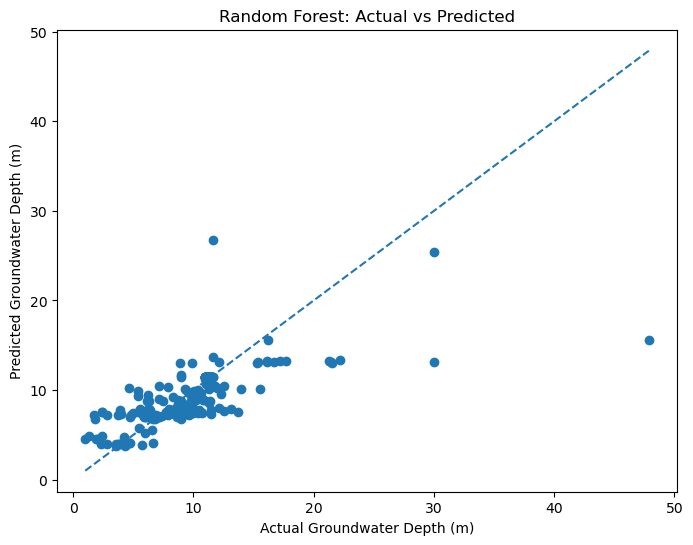

In [30]:
plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Groundwater Depth (m)")
plt.ylabel("Predicted Groundwater Depth (m)")
plt.title("Random Forest: Actual vs Predicted")

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--"
)

plt.show()

In [31]:
importance = pd.DataFrame({
    "Feature": features,
    "Importance": rf_regressor.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print(importance)

                    Feature  Importance
7                 wellDepth    0.419807
2                   t2m_max    0.235522
1                       t2m    0.149313
6                 longitude    0.080826
3                   t2m_min    0.037914
5                  latitude    0.034693
11               temp_range    0.022645
8   wellAquiferType_encoded    0.009296
4                     month    0.005886
0                  rainfall    0.004098
9             State_encoded    0.000000
10         District_encoded    0.000000


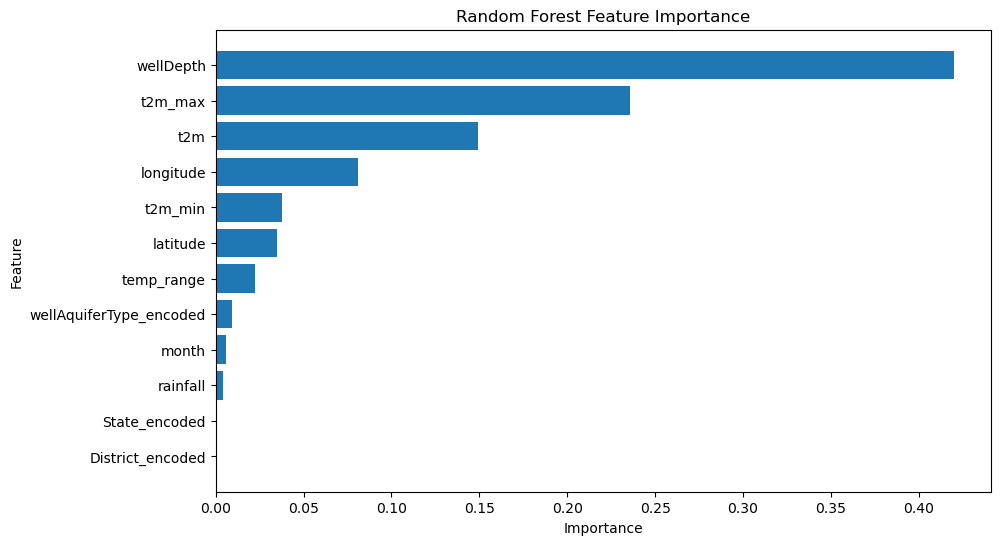

In [32]:
plt.figure(figsize=(10, 6))

plt.barh(
    importance["Feature"],
    importance["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Random Forest Feature Importance")

plt.gca().invert_yaxis()

plt.show()

In [34]:
#From now we will work on Random Forest Classification Model
df["success"] = (
    df["groundwater_depth"] <= df["wellDepth"]
).astype(int)

In [35]:
print(df["success"].value_counts())

success
1    981
0     19
Name: count, dtype: int64


In [36]:
print(df["success"].value_counts(normalize=True) * 100)

success
1    98.1
0     1.9
Name: proportion, dtype: float64


In [37]:
X_class = df[features]

y_class = df["success"]

In [38]:
X_train_class, X_test_class, y_train_class, y_test_class = train_test_split(
    X_class,
    y_class,
    test_size=0.20,
    random_state=42,
    stratify=y_class
)

In [39]:
rf_classifier = RandomForestClassifier(
    n_estimators=100,
    max_depth=3,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced"
)

In [40]:
rf_classifier.fit(
    X_train_class,
    y_train_class
)

RandomForestClassifier(class_weight='balanced', max_depth=3, n_jobs=-1,
                       random_state=42)

In [41]:
y_class_pred = rf_classifier.predict(X_test_class)

In [42]:
y_class_probability = rf_classifier.predict_proba(
    X_test_class
)[:, 1]

In [43]:
accuracy = accuracy_score(
    y_test_class,
    y_class_pred
)

precision = precision_score(
    y_test_class,
    y_class_pred,
    zero_division=0
)

recall = recall_score(
    y_test_class,
    y_class_pred,
    zero_division=0
)

f1 = f1_score(
    y_test_class,
    y_class_pred,
    zero_division=0
)

roc_auc = roc_auc_score(
    y_test_class,
    y_class_probability
)

print("Random Forest Classification Results")
print("------------------------------------")
print("Accuracy :", round(accuracy, 4))
print("Precision:", round(precision, 4))
print("Recall   :", round(recall, 4))
print("F1 Score :", round(f1, 4))
print("ROC-AUC  :", round(roc_auc, 4))

Random Forest Classification Results
------------------------------------
Accuracy : 0.915
Precision: 0.9945
Recall   : 0.9184
F1 Score : 0.9549
ROC-AUC  : 0.9528


In [44]:
cm = confusion_matrix(
    y_test_class,
    y_class_pred
)

print(cm)

[[  3   1]
 [ 16 180]]


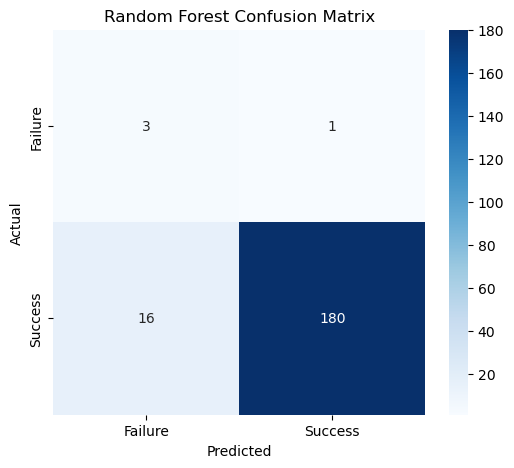

In [45]:
plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Failure", "Success"],
    yticklabels=["Failure", "Success"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest Confusion Matrix")

plt.show()

In [46]:
print(
    classification_report(
        y_test_class,
        y_class_pred,
        target_names=["Failure", "Success"],
        zero_division=0
    )
)

              precision    recall  f1-score   support

     Failure       0.16      0.75      0.26         4
     Success       0.99      0.92      0.95       196

    accuracy                           0.92       200
   macro avg       0.58      0.83      0.61       200
weighted avg       0.98      0.92      0.94       200



In [47]:
classification_importance = pd.DataFrame({
    "Feature": features,
    "Importance": rf_classifier.feature_importances_
})

classification_importance = classification_importance.sort_values(
    by="Importance",
    ascending=False
)

print(classification_importance)

                    Feature  Importance
7                 wellDepth    0.337558
5                  latitude    0.223346
6                 longitude    0.168386
11               temp_range    0.057488
3                   t2m_min    0.053231
2                   t2m_max    0.050857
1                       t2m    0.050265
4                     month    0.022867
8   wellAquiferType_encoded    0.022127
0                  rainfall    0.013876
9             State_encoded    0.000000
10         District_encoded    0.000000


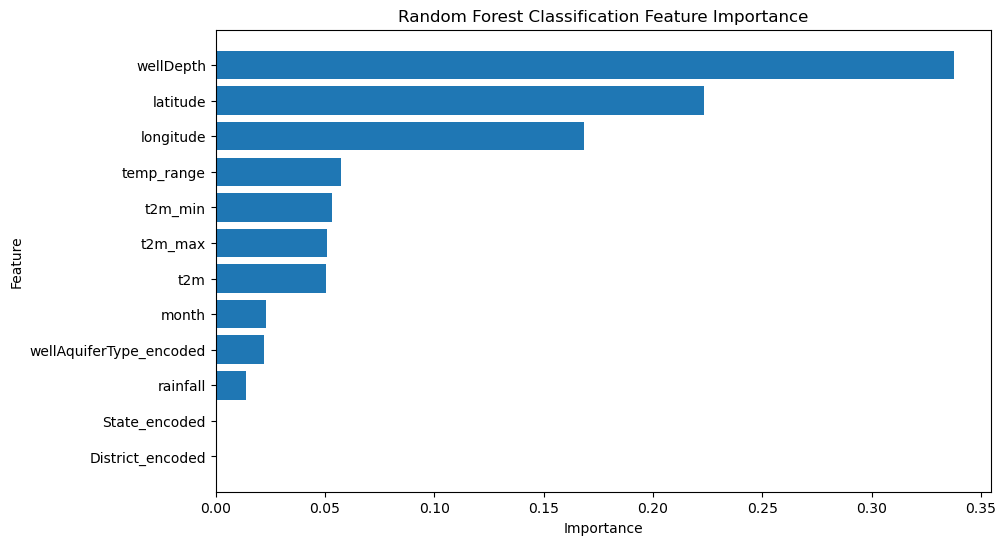

In [48]:
plt.figure(figsize=(10, 6))

plt.barh(
    classification_importance["Feature"],
    classification_importance["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Random Forest Classification Feature Importance")

plt.gca().invert_yaxis()

plt.show()

In [49]:
from sklearn.metrics import roc_auc_score

roc_auc = roc_auc_score(
    y_test_class,
    y_class_probability
)

print("ROC-AUC:", round(roc_auc, 4))

ROC-AUC: 0.9528


In [50]:
#Getting all classification results in one place
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

accuracy = accuracy_score(y_test_class, y_class_pred)

precision = precision_score(
    y_test_class,
    y_class_pred,
    zero_division=0
)

recall = recall_score(
    y_test_class,
    y_class_pred,
    zero_division=0
)

f1 = f1_score(
    y_test_class,
    y_class_pred,
    zero_division=0
)

roc_auc = roc_auc_score(
    y_test_class,
    y_class_probability
)

print("========== RANDOM FOREST CLASSIFICATION ==========")
print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1-Score  : {f1:.4f}")
print(f"ROC-AUC   : {roc_auc:.4f}")

========== RANDOM FOREST CLASSIFICATION ==========
Accuracy  : 0.9150
Precision : 0.9945
Recall    : 0.9184
F1-Score  : 0.9549
ROC-AUC   : 0.9528


In [51]:
print("========== RANDOM FOREST REGRESSION ==========")
print(f"MAE  : {mae:.4f} m")
print(f"RMSE : {rmse:.4f} m")
print(f"R²   : {r2:.4f}")

========== RANDOM FOREST REGRESSION ==========
MAE  : 1.9917 m
RMSE : 3.6884 m
R²   : 0.4725


In [52]:
#Getting your Random Forest regression feature importance
importance = pd.DataFrame({
    "Feature": features,
    "Importance": rf_regressor.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print(importance.to_string(index=False))

                Feature  Importance
              wellDepth    0.419807
                t2m_max    0.235522
                    t2m    0.149313
              longitude    0.080826
                t2m_min    0.037914
               latitude    0.034693
             temp_range    0.022645
wellAquiferType_encoded    0.009296
                  month    0.005886
               rainfall    0.004098
          State_encoded    0.000000
       District_encoded    0.000000


In [53]:
print("========== DATASET STATISTICS ==========")

print("Total rows:", len(df))
print("Total columns:", len(df.columns))

print("\nMissing values:")
print(df.isnull().sum().sum())

print("\nDuplicate rows:")
print(df.duplicated().sum())

print("\nNumber of features:", len(features))

print("\nTraining samples:", len(X_train))
print("Testing samples:", len(X_test))

print("\nClassification training samples:",
      len(X_train_class))

print("Classification testing samples:",
      len(X_test_class))

print("\nSuccess samples:", (df["success"] == 1).sum())
print("Failure samples:", (df["success"] == 0).sum())

========== DATASET STATISTICS ==========
Total rows: 1000
Total columns: 18

Missing values:
0

Duplicate rows:
0

Number of features: 12

Training samples: 800
Testing samples: 200

Classification training samples: 800
Classification testing samples: 200

Success samples: 981
Failure samples: 19


In [54]:
print("========== RANDOM FOREST PARAMETERS ==========")

print("Regression Model")
print("n_estimators:", rf_regressor.n_estimators)
print("max_depth:", rf_regressor.max_depth)
print("random_state:", rf_regressor.random_state)
print("n_jobs:", rf_regressor.n_jobs)

print("\nClassification Model")
print("n_estimators:", rf_classifier.n_estimators)
print("max_depth:", rf_classifier.max_depth)
print("random_state:", rf_classifier.random_state)
print("n_jobs:", rf_classifier.n_jobs)
print("class_weight:", rf_classifier.class_weight)

========== RANDOM FOREST PARAMETERS ==========
Regression Model
n_estimators: 100
max_depth: 4
random_state: 42
n_jobs: -1

Classification Model
n_estimators: 100
max_depth: 3
random_state: 42
n_jobs: -1
class_weight: balanced
